<a href="https://colab.research.google.com/github/rifkymaulaan/HASIL-STUDI-KASUS_GIS-ANALYST_RIFKY-MAULANA-AKBAR/blob/main/notebook/Hasil_Studi_Kasus_Rifky_Maulana_Akbar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. training sample from Google Earth Engine Catalog (sentinel-2)

In [ ]:
import ee, geemap
ee.Authenticate()
ee.Initialize(project='ilaspp-gis-analyst-509308')

adm = ee.FeatureCollection('FAO/GAUL/2015/level2')
bali = adm.filter(ee.Filter.eq('ADM1_NAME', 'Bali'))
print(adm.filter(ee.Filter.eq('ADM1_NAME', 'Bali')).aggregate_array('ADM2_NAME').getInfo())
aoi = adm.filter(ee.Filter.And(
    ee.Filter.eq('ADM1_NAME', 'Bali'),
    ee.Filter.inList('ADM2_NAME', ['Kota Denpasar','Badung','Gianyar','Tabanan'])
)).geometry()

In [ ]:
def s2_indices(year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(aoi).filterDate(f'{year}-01-01', f'{year}-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))
    def add(img):
        img = img.divide(10000)
        ndvi = img.normalizedDifference(['B8','B4']).rename('ndvi')
        mndwi = img.normalizedDifference(['B3','B11']).rename('mndwi')
        ndbi = img.normalizedDifference(['B11','B8']).rename('ndbi')
        bsi = img.expression('((S+R)-(N+B))/((S+R)+(N+B))',
              {'S':img.select('B11'),'R':img.select('B4'),
               'N':img.select('B8'),'B':img.select('B2')}).rename('bsi')
        return ndvi.addBands([mndwi, ndbi, bsi])
    return col.map(add)

def rule_labels(year):
    ic = s2_indices(year)
    ndvi = ic.select('ndvi')
    p10, p50, p90 = [ndvi.reduce(ee.Reducer.percentile([p])) for p in (10, 50, 90)]
    mndwi = ic.select('mndwi').median()
    ndbi  = ic.select('ndbi').median()
    bsi   = ic.select('bsi').median()

    water = mndwi.gt(0.2)
    forest = p50.gt(0.65).And(p10.gt(0.5)).And(water.Not())
    paddy = p90.subtract(p10).gt(0.35).And(water.Not()).And(forest.Not())
    built = ndbi.gt(0).And(p50.lt(0.25)).And(water.Not())
    bare = bsi.gt(0.05).And(p50.lt(0.15)).And(ndbi.lt(0)).And(water.Not())

    lab = (ee.Image(0).where(water,1).where(forest,2).where(paddy,3)
           .where(built,4).where(bare,5).rename('class_id'))
    return lab.selfMask().clip(aoi)

In [ ]:
pal = ['#1f78b4','#006400','#a6d854','#e31a1c','#d9b38c']  # air, vegetasi, sawah, permukiman, terbuka
vis = {'min':1, 'max':5, 'palette':pal}
l20, l23 = rule_labels(2020), rule_labels(2023)
m = geemap.Map(basemap='SATELLITE')

m.centerObject(aoi, 10)
m.addLayer(l20, vis, 'label 2020')
m.addLayer(l23, vis, 'label 2023')
m

Map(center=[-8.491999470708135, 115.15676848348734], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
stable = l20.eq(l23)
homogen = l23.focalMin(1).eq(l23.focalMax(1))
final = l23.updateMask(stable.And(homogen)).rename('class_id')

def sampel_kota(nama, n=60):
    g = bali.filter(ee.Filter.eq('ADM2_NAME', nama)).geometry()
    s = final.clip(g).stratifiedSample(
        numPoints=n, classBand='class_id', region=g,
        scale=10, seed=42, geometries=True, tileScale=8)
    return s.map(lambda f: f.set('wilayah', nama))

kota = ['Kota Denpasar', 'Badung', 'Gianyar', 'Tabanan']

parts = [sampel_kota(k) for k in kota]
samples = ee.FeatureCollection(parts).flatten()
samples = samples.randomColumn('rnd', 42).map(lambda f: ee.Feature(None, f.toDictionary()).set('split', ee.Algorithms.If(ee.Number(f.get('rnd')).lt(0.7), 'train', 'test')))

print(samples.aggregate_histogram('class_id').getInfo())

ee.batch.Export.table.toDrive(collection=samples,
    description='Training_Sample', folder='Sarbagita',
    fileFormat='SHP').start()

{'1': 240, '2': 180, '3': 240, '4': 240, '5': 82}


In [ ]:
# 2. land cover classification map (2020 2023)

In [6]:
import rasterio
import geopandas as gpd
import numpy as np
import os
from google.colab import drive
drive.mount('/content/drive')

PATH_IMG2020 = '/content/drive/MyDrive/ILASPP/Citra/Sarbagita_2020.tif'
PATH_IMG2023 = '/content/drive/MyDrive/ILASPP/Citra/Sarbagita_2023.tif'
PATH_SAMPLE  = '/content/drive/MyDrive/ILASPP/SHP/Training_Sample_Sarbagita.shp'
PATH_BATAS   = '/content/drive/MyDrive/ILASPP/SHP/batas_sarbagita.shp'
FOLDER_RESULT = '/content/drive/MyDrive/ILASPP/Result'
os.makedirs(FOLDER_RESULT, exist_ok=True)
print('Folder result siap di:', FOLDER_RESULT)

with rasterio.open(PATH_IMG2020) as src: # images
    img20 = src.read()
    profile20 = src.profile
    crs20 = src.crs
    transform20 = src.transform

with rasterio.open(PATH_IMG2023) as src:
    img23 = src.read()
    profile23 = src.profile

print('Shape img20:', img20.shape, '| Shape img23:', img23.shape)
print('Transform sama?', profile20['transform'] == profile23['transform'])

pts = gpd.read_file(PATH_SAMPLE) # training sample
print(pts.crs, pts['class_id'].value_counts())
pts = pts.to_crs(crs20)

rows, cols = rasterio.transform.rowcol(transform20, pts.geometry.x, pts.geometry.y)
rows, cols = np.array(rows), np.array(cols)

valid = (rows >= 0) & (rows < img20.shape[1]) & (cols >= 0) & (cols < img20.shape[2])
rows, cols = rows[valid], cols[valid]
pts_valid = pts.iloc[valid].reset_index(drop=True)

X = img20[:, rows, cols].T
y = pts_valid['class_id'].values
split = pts_valid['split'].values

aoi_gdf = gpd.read_file(PATH_BATAS)
print('Batas — CRS:', aoi_gdf.crs, '| jumlah fitur:', len(aoi_gdf))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder result siap di: /content/drive/MyDrive/ILASPP/Result
Shape img20: (3, 6789, 5075) | Shape img23: (3, 6789, 5075)
Transform sama? True
EPSG:4326 class_id
1    240
3    240
4    240
2    180
5     82
Name: count, dtype: int64
Batas — CRS: EPSG:4326 | jumlah fitur: 4


2020 {'tahun': 2020, 'kappa': np.float64(0.7628576602680188), 'overall_accuracy': 0.8144329896907216, 'producers_accuracy': {np.int32(1): np.float64(0.9552238805970149), np.int32(2): np.float64(0.6956521739130435), np.int32(3): np.float64(0.6714285714285714), np.int32(4): np.float64(0.8846153846153846), np.int32(5): np.float64(0.8333333333333334)}, 'users_accuracy': {np.int32(1): np.float64(0.9552238805970149), np.int32(2): np.float64(0.6153846153846154), np.int32(3): np.float64(0.7014925373134329), np.int32(4): np.float64(0.8961038961038961), np.int32(5): np.float64(0.8928571428571429)}}
Confusion matrix:
 [[64  1  0  2  0]
 [ 0 32 14  0  0]
 [ 2 19 47  2  0]
 [ 1  0  5 69  3]
 [ 0  0  1  4 25]]
2023 {'tahun': 2023, 'kappa': np.float64(0.6983685855065497), 'overall_accuracy': 0.7628865979381443, 'producers_accuracy': {np.int32(1): np.float64(0.9701492537313433), np.int32(2): np.float64(0.7391304347826086), np.int32(3): np.float64(0.44285714285714284), np.int32(4): np.float64(0.8717948

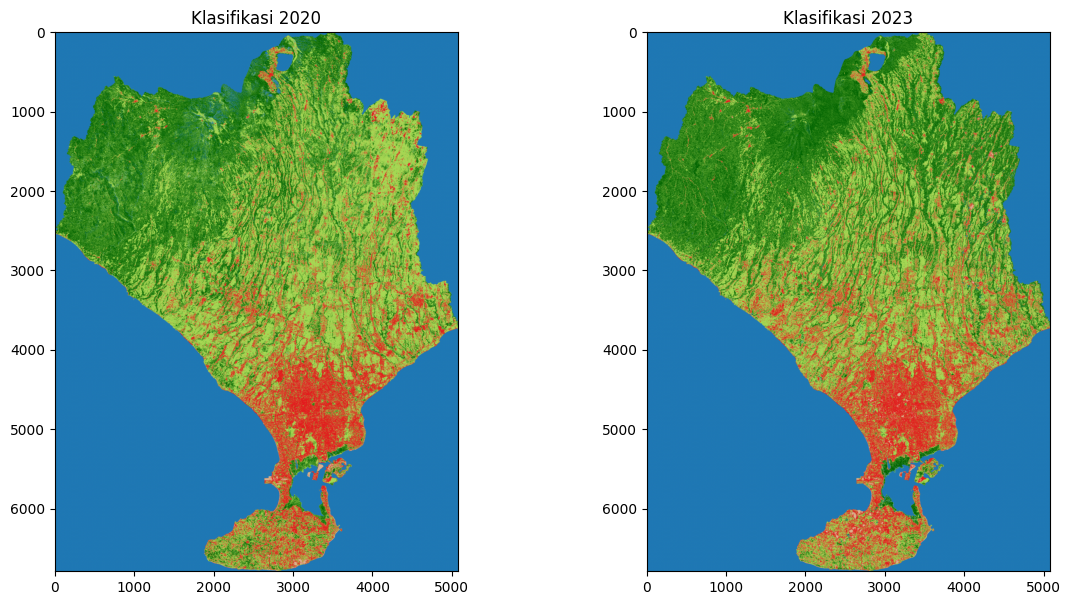

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (cohen_kappa_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def run_year(img, X, y, split, year):
    Xtr, ytr = X[split == 'train'], y[split == 'train']
    Xte, yte = X[split == 'test'],  y[split == 'test']

    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)

    pred_test = rf.predict(Xte)
    kelas = sorted(np.unique(y))

    hasil = {
        'tahun': year,
        'kappa': cohen_kappa_score(yte, pred_test),
        'overall_accuracy': accuracy_score(yte, pred_test),
        'producers_accuracy': dict(zip(kelas, recall_score(yte, pred_test, labels=kelas, average=None))),
        'users_accuracy': dict(zip(kelas, precision_score(yte, pred_test, labels=kelas, average=None))),
    }
    print(year, hasil)
    print('Confusion matrix:\n', confusion_matrix(yte, pred_test, labels=kelas))

    bands, h, w = img.shape
    flat = img.reshape(bands, -1).T
    pred_map = rf.predict(flat).reshape(h, w).astype('uint8')
    return hasil, pred_map

hasil20, map20 = run_year(img20, X, y, split, 2020)
X23 = img23[:, rows, cols].T
hasil23, map23 = run_year(img23, X23, y, split, 2023)

pal = ['#1f78b4','#006400','#a6d854','#e31a1c','#d9b38c']
cmap = ListedColormap(pal)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(map20, cmap=cmap, vmin=1, vmax=5); ax[0].set_title('Klasifikasi 2020')
ax[1].imshow(map23, cmap=cmap, vmin=1, vmax=5); ax[1].set_title('Klasifikasi 2023')
plt.show()

2020 {np.uint8(0): np.int64(16765174), np.uint8(1): np.int64(314685), np.uint8(2): np.int64(5422694), np.uint8(3): np.int64(9233307), np.uint8(4): np.int64(2595449), np.uint8(5): np.int64(122866)}
2023 {np.uint8(0): np.int64(16765174), np.uint8(1): np.int64(169632), np.uint8(2): np.int64(6037107), np.uint8(3): np.int64(8462353), np.uint8(4): np.int64(2828443), np.uint8(5): np.int64(191466)}


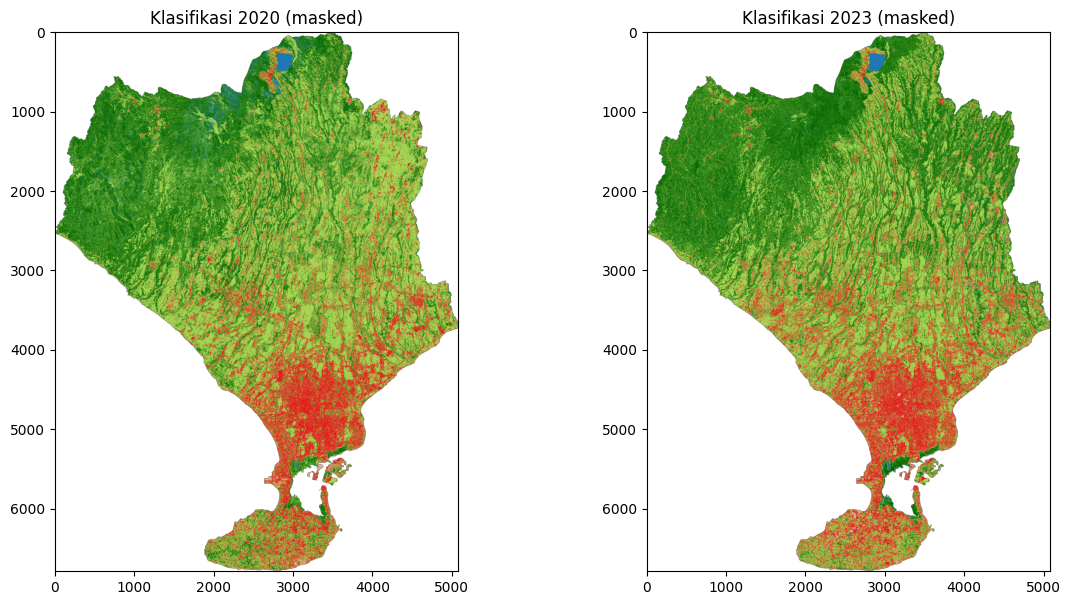

Raster final tersimpan di: /content/drive/MyDrive/ILASPP/Result/klasifikasi_2020.tif dan /content/drive/MyDrive/ILASPP/Result/klasifikasi_2023.tif


In [8]:
from rasterio.features import geometry_mask

aoi_gdf_proj = aoi_gdf.to_crs(crs20)
mask = geometry_mask(aoi_gdf_proj.geometry, out_shape=map20.shape,
                     transform=transform20, invert=True)

map20_masked = np.where(mask, map20, 0).astype('uint8')
map23_masked = np.where(mask, map23, 0).astype('uint8')

for yr, m in [(2020, map20_masked), (2023, map23_masked)]:
    unique, counts = np.unique(m, return_counts=True)
    print(yr, dict(zip(unique, counts)))

profile_out = profile20.copy()
profile_out.update(count=1, dtype='uint8', nodata=0)

path_tif_2020 = os.path.join(FOLDER_RESULT, 'klasifikasi_2020.tif')
path_tif_2023 = os.path.join(FOLDER_RESULT, 'klasifikasi_2023.tif')

with rasterio.open(path_tif_2020, 'w', **profile_out) as dst:
    dst.write(map20_masked, 1)
with rasterio.open(path_tif_2023, 'w', **profile_out) as dst:
    dst.write(map23_masked, 1)

map20_vis = np.ma.masked_where(map20_masked == 0, map20_masked)
map23_vis = np.ma.masked_where(map23_masked == 0, map23_masked)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(map20_vis, cmap=cmap, vmin=1, vmax=5); ax[0].set_title('Klasifikasi 2020 (masked)')
ax[1].imshow(map23_vis, cmap=cmap, vmin=1, vmax=5); ax[1].set_title('Klasifikasi 2023 (masked)')
plt.show()

print('Raster final tersimpan di:', path_tif_2020, 'dan', path_tif_2023)

In [12]:
import pandas as pd

rows_csv = []
for h in [hasil20, hasil23]:
    row = {'tahun': h['tahun'], 'kappa': h['kappa'], 'overall_accuracy': h['overall_accuracy']}
    for k, v in h['producers_accuracy'].items():
        row[f'PA_kelas{k}'] = v
    for k, v in h['users_accuracy'].items():
        row[f'UA_kelas{k}'] = v
    rows_csv.append(row)

path_csv = os.path.join(FOLDER_RESULT, 'akurasi_klasifikasi.csv')
pd.DataFrame(rows_csv).to_csv(path_csv, index=False)
print('Tabel akurasi tersimpan di:', path_csv)

Tabel akurasi tersimpan di: /content/drive/MyDrive/ILASPP/Result/akurasi_klasifikasi.csv


In [15]:
from sklearn.metrics import recall_score, precision_score
import pandas as pd
from google.colab import drive

# 1. Hubungkan (Mount) Google Drive ke Colab (jika belum)
drive.mount('/content/drive')

# 2. Perhitungan Akurasi (Script Asli Anda)
pa_trans = recall_score(yte, pred_te, labels=[0, 1], average=None)
ua_trans = precision_score(yte, pred_te, labels=[0, 1], average=None)

print('PA model transisi (0=tidak berubah, 1=berubah):', dict(zip([0,1], pa_trans)))
print('UA model transisi:', dict(zip([0,1], ua_trans)))

# 3. Merapikan Hasil ke dalam Tabel (DataFrame)
df_akurasi = pd.DataFrame({
    'Kelas': ['0 (Tidak Berubah)', '1 (Berubah)'],
    'Producers_Accuracy_PA': pa_trans,
    'Users_Accuracy_UA': ua_trans
})

# 4. Tentukan Lokasi Simpan di Google Drive
# Sesuaikan 'Tugas_GIS_Sarbagita' dengan nama folder Anda di Drive
lokasi_simpan = '/content/drive/MyDrive/ILASPP/Result/akurasi_transisi.csv'

# 5. Ekspor ke CSV
df_akurasi.to_csv(lokasi_simpan, index=False)
print(f"\nBerhasil! File akurasi telah disimpan di: {lokasi_simpan}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PA model transisi (0=tidak berubah, 1=berubah): {0: np.float64(0.5584512739111619), 1: np.float64(0.6074850543384882)}
UA model transisi: {0: np.float64(0.6954611554156633), 1: np.float64(0.46153998210494085)}

Berhasil! File akurasi telah disimpan di: /content/drive/MyDrive/ILASPP/Result/akurasi_transisi.csv


In [ ]:
# 3. driving and restricting factor

In [ ]:
# generate supporting data for driving n restricting factor

In [ ]:
from scipy.ndimage import distance_transform_edt

# residental
permukiman_mask = (map23_masked == 4)
dist_permukiman = distance_transform_edt(~permukiman_mask) * 10  # skala 10 m/piksel -> meter

# slope
import ee
ee.Authenticate()
ee.Initialize(project='ilaspp-gis-analyst-509308')

adm = ee.FeatureCollection('FAO/GAUL/2015/level2')
bali = adm.filter(ee.Filter.eq('ADM1_NAME', 'Bali'))
aoi = adm.filter(ee.Filter.And(
    ee.Filter.eq('ADM1_NAME', 'Bali'),
    ee.Filter.inList('ADM2_NAME', ['Kota Denpasar','Badung','Gianyar','Tabanan'])
)).geometry()
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi)
slope = ee.Terrain.slope(dem)

ee.batch.Export.image.toDrive(
    image=slope, description='slope_sarbagita',
    folder='ILASPP/Citra', region=aoi, scale=10,
    crs='EPSG:4326', maxPixels=1e10).start()

# road
!pip install osmnx -q
import osmnx as ox

bounds = aoi_gdf.total_bounds  # [minx, miny, maxx, maxy]
bbox = (bounds[0], bounds[1], bounds[2], bounds[3])  # (west, south, east, north)

graph = ox.graph_from_bbox(bbox=bbox, network_type='drive')
edges = ox.graph_to_gdfs(graph, nodes=False)
edges = edges.to_crs(crs20)


# water body
restrict_air = (map23_masked == 1)

# wdpa GEE
import ee
ee.Authenticate()
ee.Initialize(project='ilaspp-gis-analyst-509308')
adm = ee.FeatureCollection('FAO/GAUL/2015/level2')
bali = adm.filter(ee.Filter.eq('ADM1_NAME', 'Bali'))
aoi = bali.filter(ee.Filter.inList('ADM2_NAME', ['Kota Denpasar','Badung','Gianyar','Tabanan'])).geometry()
wdpa = ee.FeatureCollection('WCMC/WDPA/current/polygons').filterBounds(aoi)
print(wdpa.size().getInfo())   # cek dulu ada isinya atau tidak di Sarbagita
wdpa_darat = wdpa.filter(ee.Filter.inList('DESIG_ENG', [
    'Nature Reserve', 'Grand Forest Park', 'Nature Recreation Park'
]))
print(wdpa_darat.size().getInfo())

wdpa_raster = ee.Image(0).paint(wdpa_darat, 1).clip(aoi)

ee.batch.Export.image.toDrive(
    image=wdpa_raster, description='wdpa_mask_sarbagita_darat',
    folder='ILASPP/Citra', region=aoi, scale=10,
    crs='EPSG:4326', maxPixels=1e10).start()

info = wdpa.select(['NAME', 'DESIG_ENG', 'IUCN_CAT']).getInfo()
for f in info['features']:
    print(f['properties'])

# river
# from shp (inageoportal)

In [15]:
import rasterio
import geopandas as gpd
import numpy as np
import osmnx as ox
from scipy.ndimage import distance_transform_edt
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling

FOLDER_CITRA = '/content/drive/MyDrive/ILASPP/Citra'

permukiman_mask = (map23_masked == 4)
dist_permukiman = distance_transform_edt(~permukiman_mask) * 10 # dist to residental


with rasterio.open(f'{FOLDER_CITRA}/slope_sarbagita.tif') as src: # slope
    slope_raw = src.read(1)
    slope_transform = src.transform
    slope_crs = src.crs

if (slope_raw.shape != map23_masked.shape) or (slope_transform != transform20):
    slope = np.zeros(map23_masked.shape, dtype='float32')
    reproject(source=slope_raw, destination=slope,
              src_transform=slope_transform, src_crs=slope_crs,
              dst_transform=transform20, dst_crs=crs20,
              resampling=Resampling.bilinear)
else:
    slope = slope_raw


aoi_union = aoi_gdf.to_crs(4326).union_all() # dist to road
graph = ox.graph_from_polygon(aoi_union, network_type='drive')
edges = ox.graph_to_gdfs(graph, nodes=False).to_crs(crs20)

jalan_raster = rasterize([(geom, 1) for geom in edges.geometry],
                         out_shape=map23_masked.shape, transform=transform20,
                         fill=0, dtype='uint8')
dist_jalan = distance_transform_edt(jalan_raster == 0) * 10

print('dist_permukiman:', dist_permukiman.shape, dist_permukiman.dtype)
print('slope:', slope.shape, slope.dtype)
print('dist_jalan:', dist_jalan.shape, dist_jalan.dtype)

dist_permukiman: (6789, 5075) float64
slope: (6789, 5075) float32
dist_jalan: (6789, 5075) float64


In [10]:
restrict_air = (map23_masked == 1) # water body


with rasterio.open(f'{FOLDER_CITRA}/wdpa_mask_sarbagita_darat.tif') as src:
    wdpa_raw = src.read(1)
    wdpa_transform = src.transform
    wdpa_crs = src.crs

if (wdpa_raw.shape != map23_masked.shape) or (wdpa_transform != transform20):
    wdpa_mask = np.zeros(map23_masked.shape, dtype='uint8')
    reproject(source=wdpa_raw, destination=wdpa_mask,
              src_transform=wdpa_transform, src_crs=wdpa_crs,
              dst_transform=transform20, dst_crs=crs20,
              resampling=Resampling.nearest)
    wdpa_mask = wdpa_mask.astype(bool)
else:
    wdpa_mask = wdpa_raw.astype(bool) #wdpa


dist_air = distance_transform_edt(~restrict_air) * 10
sungai_gdf = gpd.read_file('/content/drive/MyDrive/ILASPP/SHP/sungai_sarbagita.shp')
sungai_gdf_m = sungai_gdf.to_crs(32750)   # UTM zone 50S unit meter
sungai_buffer_m = sungai_gdf_m.buffer(20)

sungai_buffer = gpd.GeoSeries(sungai_buffer_m, crs=32750).to_crs(crs20)

restrict_sempadan = rasterize(
    [(geom, 1) for geom in sungai_buffer],
    out_shape=map23_masked.shape, transform=transform20,
    fill=0, dtype='uint8').astype(bool) # river

restrict_total = restrict_air | wdpa_mask | restrict_sempadan

print('restrict_air:', restrict_air.sum())
print('wdpa_mask:', wdpa_mask.sum())
print('restrict_sempadan (dari shp sungai):', restrict_sempadan.sum())
print('restrict_total (union):', restrict_total.sum())
print('restrict_air:', restrict_air.sum())
print('wdpa_mask:', wdpa_mask.sum())
print('restrict_sempadan:', restrict_sempadan.sum())
print('restrict_total (union):', restrict_total.sum())

restrict_air: 169632
wdpa_mask: 234710
restrict_sempadan (dari shp sungai): 72237
restrict_total (union): 458329
restrict_air: 169632
wdpa_mask: 234710
restrict_sempadan: 72237
restrict_total (union): 458329


In [11]:
import os

profile_factor = profile20.copy()
profile_factor.update(count=1, dtype='float32', nodata=None)

factors = {
    'dist_permukiman.tif': dist_permukiman.astype('float32'),
    'slope.tif': slope.astype('float32'),
    'dist_jalan.tif': dist_jalan.astype('float32'),
    'restrict_total.tif': restrict_total.astype('uint8'),
}

for name, arr in factors.items():
    p = profile_factor.copy() if arr.dtype == np.float32 else {**profile_factor, 'dtype': 'uint8'}
    with rasterio.open(os.path.join(FOLDER_RESULT, name), 'w', **p) as dst:
        dst.write(arr, 1)

print('Semua faktor tersimpan di', FOLDER_RESULT)

Semua faktor tersimpan di /content/drive/MyDrive/ILASPP/Result


In [ ]:
# save cache

In [16]:
import numpy as np
import os

FOLDER_CACHE = '/content/drive/MyDrive/ILASPP/Cache'
os.makedirs(FOLDER_CACHE, exist_ok=True)

np.savez_compressed(
    os.path.join(FOLDER_CACHE, 'data_sarbagita.npz'),
    map20_masked=map20_masked,
    map23_masked=map23_masked,
    dist_permukiman=dist_permukiman.astype('float32'),
    slope=slope.astype('float32'),
    dist_jalan=dist_jalan.astype('float32'),
    restrict_total=restrict_total,
)
print('Tersimpan di', os.path.join(FOLDER_CACHE, 'data_sarbagita.npz'))
import pickle
with open(os.path.join(FOLDER_CACHE, 'meta_sarbagita.pkl'), 'wb') as f:
    pickle.dump({'profile20': profile20, 'crs20': crs20, 'transform20': transform20}, f)
print('Meta tersimpan.')

Tersimpan di /content/drive/MyDrive/ILASPP/Cache/data_sarbagita.npz
Meta tersimpan.


In [2]:
import numpy as np
import pickle
import os
from google.colab import drive
drive.mount('/content/drive')

FOLDER_CACHE = '/content/drive/MyDrive/ILASPP/Cache'

data = np.load(os.path.join(FOLDER_CACHE, 'data_sarbagita.npz'))
map20_masked = data['map20_masked']
map23_masked = data['map23_masked']
dist_permukiman = data['dist_permukiman']
slope = data['slope']
dist_jalan = data['dist_jalan']
restrict_total = data['restrict_total']

with open(os.path.join(FOLDER_CACHE, 'meta_sarbagita.pkl'), 'rb') as f:
    meta = pickle.load(f)
profile20 = meta['profile20']
crs20 = meta['crs20']
transform20 = meta['transform20']

print('Semua variabel berhasil dimuat dari cache.')
print('map20_masked:', map20_masked.shape)
print('map23_masked:', map23_masked.shape)

Mounted at /content/drive
Semua variabel berhasil dimuat dari cache.
map20_masked: (6789, 5075)
map23_masked: (6789, 5075)


In [ ]:
# transition model 2020-2023

In [3]:
import gc

valid = (map20_masked != 0) & (map23_masked != 0)
berubah = (map20_masked != map23_masked) & valid

X_valid = np.stack([
    dist_permukiman[valid].astype('float32'),
    slope[valid].astype('float32'),
    dist_jalan[valid].astype('float32')
], axis=-1)
y_valid = berubah[valid].astype('uint8')

del dist_permukiman, slope, dist_jalan
gc.collect()

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(
    X_valid, y_valid, test_size=0.3, random_state=42, stratify=y_valid)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score

rf_trans = RandomForestClassifier(n_estimators=150, max_depth=15,
                                  random_state=42, n_jobs=2, class_weight='balanced')
rf_trans.fit(Xtr, ytr)

pred_te = rf_trans.predict(Xte)
print('Accuracy:', accuracy_score(yte, pred_te))
print('Kappa:', cohen_kappa_score(yte, pred_te))
print('Proporsi berubah aktual:', y_valid.mean())

Accuracy: 0.5772735264338428
Kappa: 0.15660224846401039
Proporsi berubah aktual: 0.38386288745192565


In [ ]:
# 4. projection to 2026

In [5]:
# join all (transition+target+factor 2023)
from sklearn.ensemble import RandomForestClassifier
from scipy.ndimage import distance_transform_edt

data = np.load(os.path.join(FOLDER_CACHE, 'data_sarbagita.npz'))
slope = data['slope']
dist_jalan = data['dist_jalan']

permukiman_2023 = (map23_masked == 4)
dist_permukiman_2023 = distance_transform_edt(~permukiman_2023) * 10

mask_berubah = berubah[valid]
X_tujuan = X_valid[mask_berubah]
y_tujuan = map23_masked[valid][mask_berubah]

rf_tujuan = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   random_state=42, n_jobs=-1, class_weight='balanced')
rf_tujuan.fit(X_tujuan, y_tujuan)

print('Sampel latih model tujuan:', len(y_tujuan))
print('Distribusi kelas tujuan:', dict(zip(*np.unique(y_tujuan, return_counts=True))))

Sampel latih model tujuan: 6790151
Distribusi kelas tujuan: {np.uint8(1): np.int64(121458), np.uint8(2): np.int64(2650333), np.uint8(3): np.int64(2761621), np.uint8(4): np.int64(1118668), np.uint8(5): np.int64(138071)}


In [ ]:
# projection map 2026
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import ListedColormap
from scipy.ndimage import distance_transform_edt
from sklearn.ensemble import RandomForestClassifier

FOLDER_RESULT = '/content/drive/MyDrive/ILASPP/Result'

dist_air_2023 = distance_transform_edt(~(map23_masked == 1)) * 10
dist_air_valid = dist_air_2023[valid].astype('float32')

X_proj = np.stack([
    dist_permukiman_2023[valid].astype('float32'),
    slope[valid].astype('float32'),
    dist_jalan[valid].astype('float32'),
    dist_air_valid
], axis=-1)

mask_berubah = berubah[valid]
X_tujuan = X_proj[mask_berubah]
y_tujuan = map23_masked[valid][mask_berubah]

rf_tujuan = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   random_state=42, n_jobs=-1, class_weight='balanced')
rf_tujuan.fit(X_tujuan, y_tujuan)

pred_berubah_2026 = rf_trans.predict(X_proj[:, :3])
pred_kelas_2026 = rf_tujuan.predict(X_proj)

kelas_2023_flat = map23_masked[valid]
restrict_flat = restrict_total[valid]

proyeksi_flat = np.where(
    (pred_berubah_2026 == 1) & (~restrict_flat),
    pred_kelas_2026, kelas_2023_flat
).astype('uint8')

proyeksi_2026 = np.zeros(map23_masked.shape, dtype='uint8')
proyeksi_2026[valid] = proyeksi_flat

print('Proyeksi 2026:', dict(zip(*np.unique(proyeksi_2026, return_counts=True))))
print('2023 (pembanding):', dict(zip(*np.unique(map23_masked, return_counts=True))))

profile_out = profile20.copy()
profile_out.update(count=1, dtype='uint8', nodata=0)
path_proyeksi = os.path.join(FOLDER_RESULT, 'proyeksi_2026_v2.tif')
with rasterio.open(path_proyeksi, 'w', **profile_out) as dst:
    dst.write(proyeksi_2026, 1)
print('Tersimpan:', path_proyeksi)

pal = ['#1f78b4','#006400','#a6d854','#e31a1c','#d9b38c']
cmap = ListedColormap(pal)
proyeksi_vis = np.ma.masked_where(proyeksi_2026 == 0, proyeksi_2026)
map23_vis = np.ma.masked_where(map23_masked == 0, map23_masked)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(map23_vis, cmap=cmap, vmin=1, vmax=5)
ax[0].set_title('Klasifikasi 2023')
ax[1].imshow(proyeksi_vis, cmap=cmap, vmin=1, vmax=5)
ax[1].set_title('Proyeksi 2026 (4 fitur)')
plt.show()

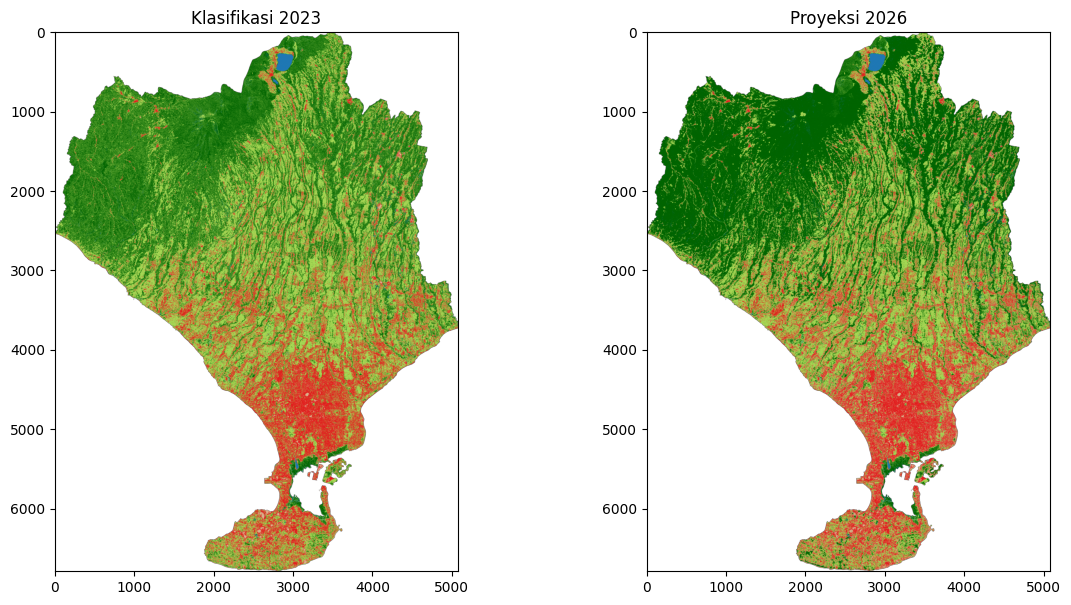

In [13]:
proyeksi_vis_v2 = np.ma.masked_where(proyeksi_2026_v2 == 0, proyeksi_2026_v2)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(map23_vis, cmap=cmap, vmin=1, vmax=5)
ax[0].set_title('Klasifikasi 2023')
ax[1].imshow(proyeksi_vis_v2, cmap=cmap, vmin=1, vmax=5)
ax[1].set_title('Proyeksi 2026')
plt.show()

In [24]:
# LIST WDPA BALI

{'DESIG_ENG': 'Marine Protected Area', 'IUCN_CAT': 'Not Reported', 'NAME': 'KKP-03 Kuta Badung'}
{'DESIG_ENG': 'Marine Protected Area', 'IUCN_CAT': 'Not Reported', 'NAME': 'KKP-04 Kuta Selatan Badung'}
{'DESIG_ENG': 'Maritime Park', 'IUCN_CAT': 'III', 'NAME': 'KKM Teluk Benoa'}
{'DESIG_ENG': 'Nature Reserve', 'IUCN_CAT': 'Ia', 'NAME': 'Batukahu I-II-III'}
{'DESIG_ENG': 'Grand Forest Park', 'IUCN_CAT': 'VI', 'NAME': 'Ngurah Rai'}
{'DESIG_ENG': 'Nature Recreation Park', 'IUCN_CAT': 'V', 'NAME': 'Danau Buyan - Danau Tamblingan'}
{'DESIG_ENG': 'Nature Recreation Park', 'IUCN_CAT': 'III', 'NAME': 'Sangeh'}
